In [ ]:
# =========================================================
# CELL 1: MOUNT GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================================================
# CELL 2: IMPORT LIBRARIES
# =========================================================
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
# =========================================================
# CELL 3: PATHS
# Put your ZIP in Drive once and reuse forever
# Example: MyDrive/chest-xray-pneumonia.zip
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ZIP_PATH = "/content/drive/MyDrive/archive (7).zip"   # change only if needed
EXTRACT_ROOT = "/content"                                      # fast local runtime
DATA_DIR = "/content/chest_xray"                               # extracted folder

IMG_SIZE = 224
PATCH_SIZE = 16
BATCH_SIZE = 32
EMBED_DIM = 128
NUM_CLASSES = 2
EPOCHS = 30
LR = 1e-4
NUM_WORKERS = 2

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

print("Using Device:", DEVICE)
print("ZIP Path:", ZIP_PATH)

Using Device: cuda
ZIP Path: /content/drive/MyDrive/archive (7).zip


In [ ]:
# =========================================================
# CELL 4: VERIFY ZIP EXISTS
# =========================================================
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP not found at: {ZIP_PATH}")

print("ZIP file found.")
print(f"ZIP size: {os.path.getsize(ZIP_PATH) / (1024**2):.2f} MB")

ZIP file found.
ZIP size: 2349.25 MB


In [ ]:
# =========================================================
# CELL 5: UNZIP ONLY IF NEEDED
# Prevents extracting again and again every session cell rerun
# =========================================================
if not os.path.exists(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_ROOT)
    print("Extraction completed.")
else:
    print("Dataset already extracted. Skipping unzip.")

Dataset already extracted. Skipping unzip.


In [ ]:
# =========================================================
# CELL 6: CREATE PROPER TRAIN / VALIDATION SPLIT
# Ignore original val/ (too small and unreliable)
# Use train/ only and split it into:
# 80% Train / 20% Validation
# Keep test/ unchanged
# =========================================================
from torch.utils.data import random_split

full_train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

# 80-20 split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# reproducible split
torch.manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))

Train Size: 4172
Validation Size: 1044
Test Size: 624


In [ ]:
# =========================================================
# CELL 7: DATA LOADERS
# =========================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
# =========================================================
# CELL 8: VERIFY NEW DATASET DISTRIBUTION
# =========================================================
train_targets = [full_train_dataset.targets[i] for i in train_dataset.indices]
val_targets   = [full_train_dataset.targets[i] for i in val_dataset.indices]
test_targets  = test_dataset.targets

train_counts = np.bincount(train_targets)
val_counts   = np.bincount(val_targets)
test_counts  = np.bincount(test_targets)

print("==== New Dataset Distribution ====")
print(f"{'Split':<10}{'NORMAL':<12}{'PNEUMONIA':<15}{'TOTAL':<10}")
print("-"*45)
print(f"{'Train':<10}{train_counts[0]:<12}{train_counts[1]:<15}{len(train_dataset):<10}")
print(f"{'Val':<10}{val_counts[0]:<12}{val_counts[1]:<15}{len(val_dataset):<10}")
print(f"{'Test':<10}{test_counts[0]:<12}{test_counts[1]:<15}{len(test_dataset):<10}")

==== New Dataset Distribution ====
Split     NORMAL      PNEUMONIA      TOTAL     
---------------------------------------------
Train     1058        3114           4172      
Val       283         761            1044      
Test      234         390            624       


In [ ]:
# =========================================================
# CELL 8: VERIFY NEW DATASET DISTRIBUTION
# =========================================================
train_targets = [full_train_dataset.targets[i] for i in train_dataset.indices]
val_targets   = [full_train_dataset.targets[i] for i in val_dataset.indices]
test_targets  = test_dataset.targets

train_counts = np.bincount(train_targets)
val_counts   = np.bincount(val_targets)
test_counts  = np.bincount(test_targets)

print("==== New Dataset Distribution ====")
print(f"{'Split':<10}{'NORMAL':<12}{'PNEUMONIA':<15}{'TOTAL':<10}")
print("-"*45)
print(f"{'Train':<10}{train_counts[0]:<12}{train_counts[1]:<15}{len(train_dataset):<10}")
print(f"{'Val':<10}{val_counts[0]:<12}{val_counts[1]:<15}{len(val_dataset):<10}")
print(f"{'Test':<10}{test_counts[0]:<12}{test_counts[1]:<15}{len(test_dataset):<10}")

==== New Dataset Distribution ====
Split     NORMAL      PNEUMONIA      TOTAL     
---------------------------------------------
Train     1058        3114           4172      
Val       283         761            1044      
Test      234         390            624       


In [ ]:
# =========================================================
# CELL 10: SANITY CHECK BATCH
# =========================================================
images, labels = next(iter(train_loader))

print("Batch Image Shape:", images.shape)
print("Batch Labels Shape:", labels.shape)

assert images.shape[1:] == (3, 224, 224), "Image shape mismatch"
assert labels.ndim == 1, "Label shape mismatch"

print("Batch sanity check passed.")

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Labels Shape: torch.Size([32])
Batch sanity check passed.


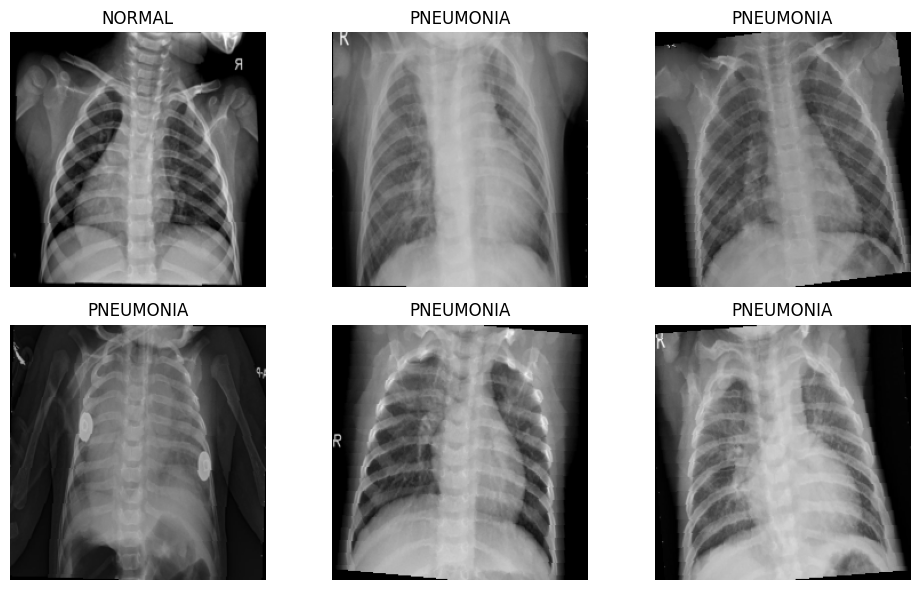

In [ ]:
# =========================================================
# CELL 11: VISUALIZE SAMPLE IMAGES
# =========================================================
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 12: PATCH EMBEDDING
# =========================================================
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)       # [B, E, 14, 14]
        x = x.flatten(2)       # [B, E, 196]
        x = x.transpose(1, 2)  # [B, 196, E]
        return x

In [ ]:
# =========================================================
# CELL 13: MODEL
# =========================================================
class VisionAttentionNet(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=128, num_classes=2):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim
        )

        num_patches = (img_size // patch_size) ** 2

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=1,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embedding

        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        x = x.mean(dim=1)   # global average pooling over patches
        x = self.classifier(x)

        return x

In [ ]:
# =========================================================
# CELL 14: INITIALIZE MODEL
# =========================================================
model = VisionAttentionNet(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(model)

# forward-pass sanity check
with torch.no_grad():
    sample_out = model(images[:2].to(DEVICE))
    print("Output Shape:", sample_out.shape)

assert sample_out.shape == (2, 2), "Model output shape mismatch"
print("Model sanity check passed.")

VisionAttentionNet(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(16, 16), stride=(16, 16))
  )
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)
Output Shape: torch.Size([2, 2])
Model sanity check passed.


In [ ]:
# =========================================================
# CELL 15: TRAIN FUNCTION
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
# =========================================================
# CELL 16: EVALUATION FUNCTION
# =========================================================
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [ ]:
# =========================================================
# CELL 17: TRAIN MODEL WITH EARLY STOPPING
# =========================================================
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
patience = 6
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

Epoch [1/30] | Train Loss: 0.5531 | Train Acc: 0.7452 | Val Loss: 0.4833 | Val Acc: 0.7395
Epoch [2/30] | Train Loss: 0.3658 | Train Acc: 0.8344 | Val Loss: 0.3462 | Val Acc: 0.8611
Epoch [3/30] | Train Loss: 0.3026 | Train Acc: 0.8797 | Val Loss: 0.2879 | Val Acc: 0.8956
Epoch [4/30] | Train Loss: 0.2792 | Train Acc: 0.8897 | Val Loss: 0.2598 | Val Acc: 0.8946
Epoch [5/30] | Train Loss: 0.2565 | Train Acc: 0.8981 | Val Loss: 0.2440 | Val Acc: 0.8937
Epoch [6/30] | Train Loss: 0.2538 | Train Acc: 0.9008 | Val Loss: 0.2282 | Val Acc: 0.9119
Epoch [7/30] | Train Loss: 0.2407 | Train Acc: 0.8984 | Val Loss: 0.2308 | Val Acc: 0.9176
Epoch [8/30] | Train Loss: 0.2308 | Train Acc: 0.9094 | Val Loss: 0.2142 | Val Acc: 0.9176
Epoch [9/30] | Train Loss: 0.2252 | Train Acc: 0.9147 | Val Loss: 0.2171 | Val Acc: 0.9205
Epoch [10/30] | Train Loss: 0.2153 | Train Acc: 0.9195 | Val Loss: 0.2201 | Val Acc: 0.9167
Epoch [11/30] | Train Loss: 0.2147 | Train Acc: 0.9216 | Val Loss: 0.1935 | Val Acc: 0.92

In [ ]:
# =========================================================
# CELL 18: TEST MODEL
# =========================================================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

print(f"\nTest Accuracy: {test_acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Test Accuracy: 0.8013

              precision    recall  f1-score   support

      NORMAL       0.88      0.55      0.67       234
   PNEUMONIA       0.78      0.95      0.86       390

    accuracy                           0.80       624
   macro avg       0.83      0.75      0.77       624
weighted avg       0.82      0.80      0.79       624



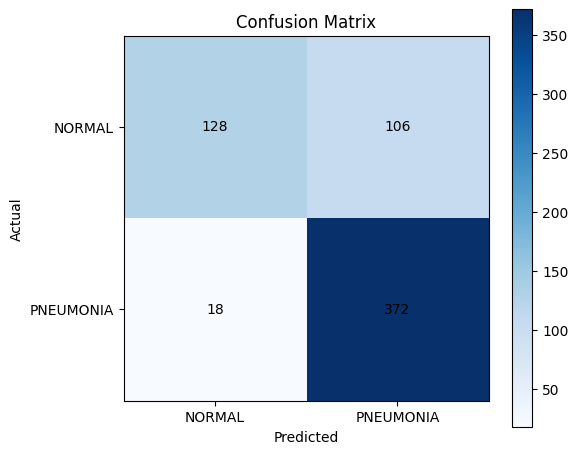

In [ ]:
# =========================================================
# CELL 19: CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], CLASS_NAMES)
plt.yticks([0, 1], CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

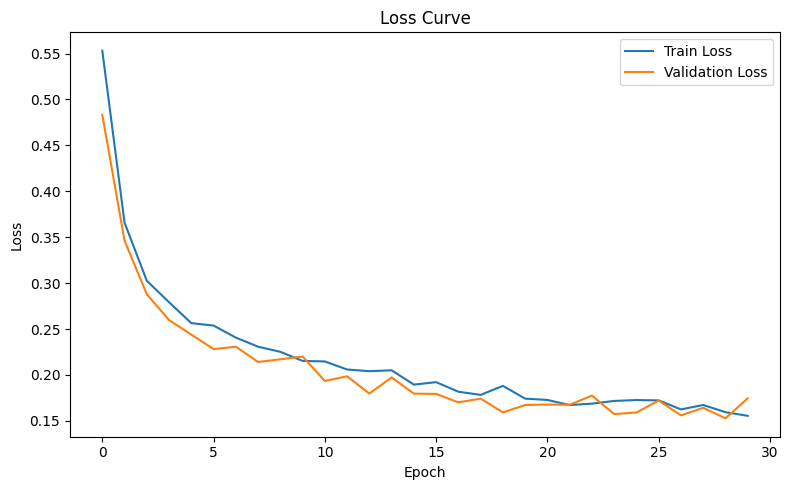

In [ ]:
# =========================================================
# CELL 20: LOSS CURVE
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

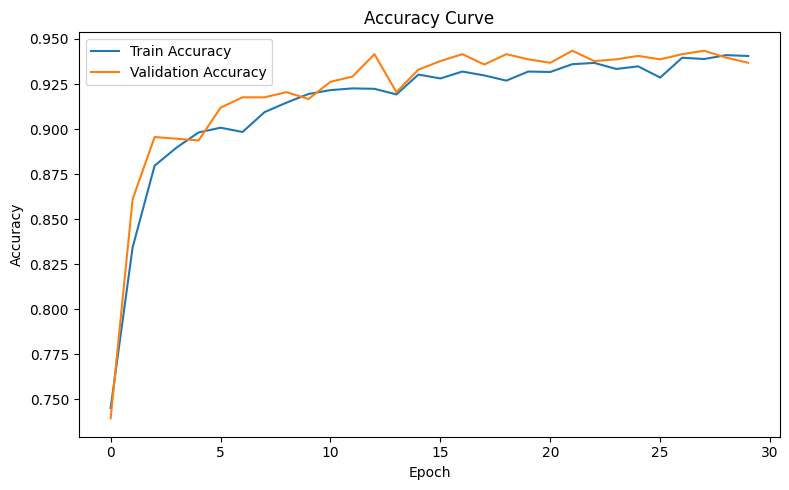

In [ ]:
# =========================================================
# CELL 21: ACCURACY CURVE
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

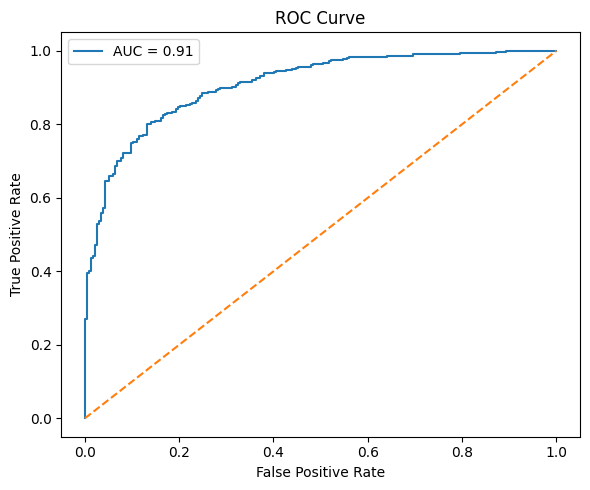

In [ ]:
# =========================================================
# CELL 22: ROC CURVE
# =========================================================
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 23: MEDICAL METRICS (Sensitivity / Specificity / PR-AUC)
# =========================================================
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
precision   = precision_score(y_true, y_pred)
recall      = recall_score(y_true, y_pred)                 # Sensitivity
specificity = tn / (tn + fp)
f1          = f1_score(y_true, y_pred)
roc_auc_val = auc(*roc_curve(y_true, y_prob)[:2])
pr_auc      = average_precision_score(y_true, y_prob)

print("==== Medical Metrics ====")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc_val:.4f}")
print(f"PR-AUC       : {pr_auc:.4f}")

==== Medical Metrics ====
Accuracy     : 0.8013
Precision    : 0.7782
Sensitivity  : 0.9538
Specificity  : 0.5470
F1-Score     : 0.8571
ROC-AUC      : 0.9086
PR-AUC       : 0.9447


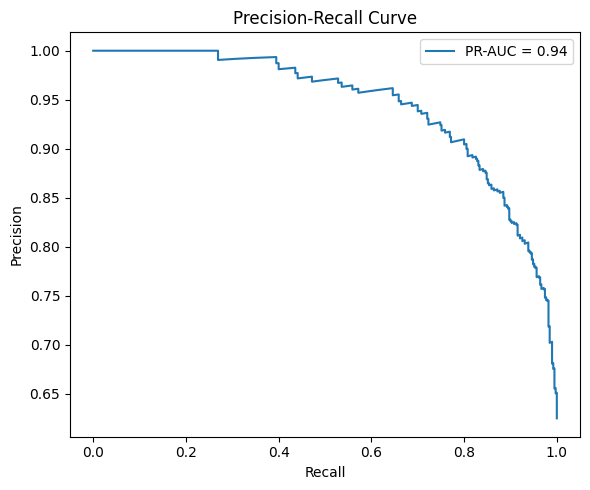

In [ ]:
# =========================================================
# CELL 24: PRECISION-RECALL CURVE
# =========================================================
from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 27: INFERENCE TIME PER IMAGE
# =========================================================
import time

model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

# warmup
for _ in range(10):
    _ = model(dummy)

runs = 100
start = time.time()
with torch.no_grad():
    for _ in range(runs):
        _ = model(dummy)
end = time.time()

avg_time = (end - start) / runs
print("==== Inference Speed ====")
print(f"Average Inference Time / Image: {avg_time*1000:.2f} ms")

==== Inference Speed ====
Average Inference Time / Image: 1.59 ms


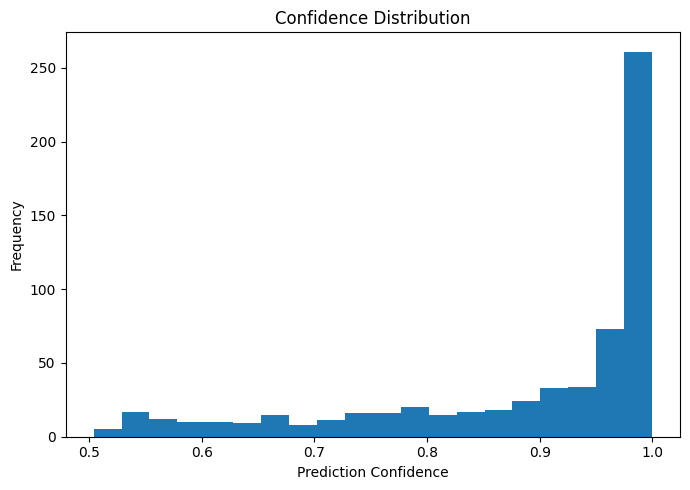

In [ ]:
# =========================================================
# CELL 28: CONFIDENCE HISTOGRAM
# =========================================================
confidence = np.max(np.stack([1 - y_prob, y_prob], axis=1), axis=1)

plt.figure(figsize=(7,5))
plt.hist(confidence, bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")
plt.tight_layout()
plt.show()

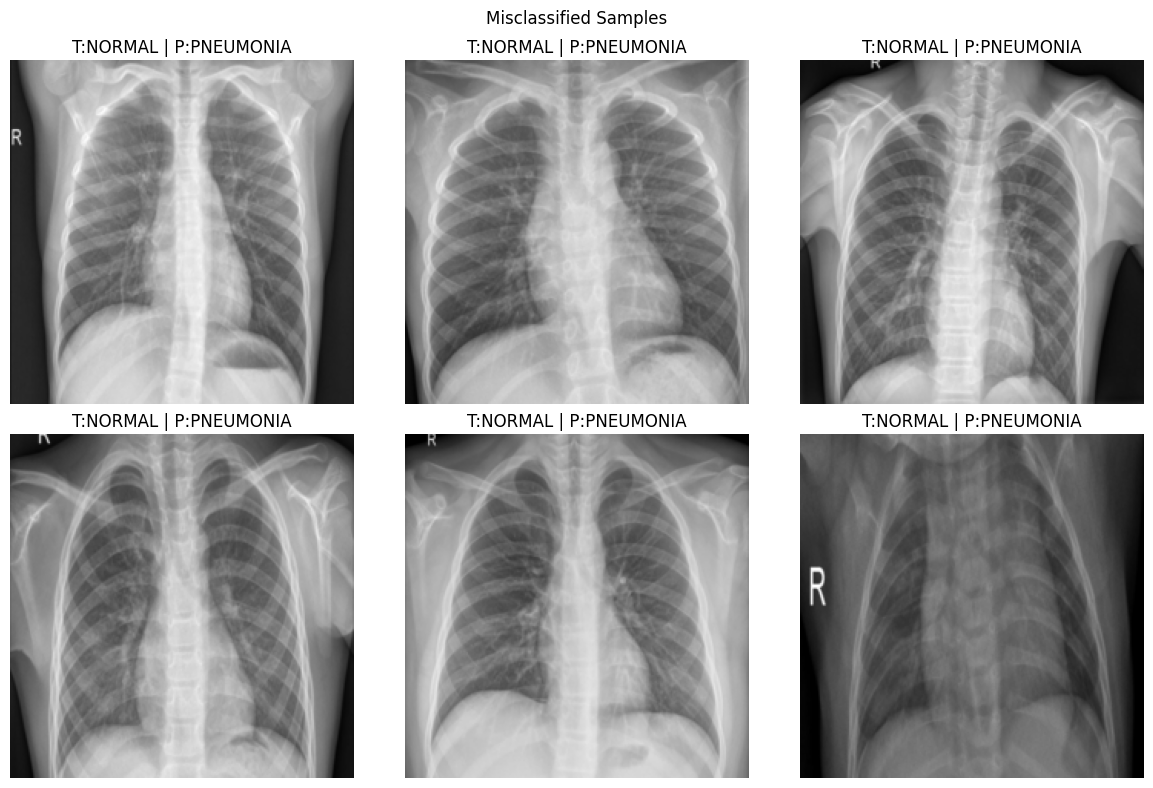

In [ ]:
# =========================================================
# CELL 29: MISCLASSIFIED SAMPLES
# =========================================================
mis_idx = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(mis_idx[:6]):
    img, label = test_dataset[idx]
    img_disp = img.permute(1, 2, 0).numpy()
    img_disp = (img_disp * 0.5) + 0.5
    img_disp = np.clip(img_disp, 0, 1)

    plt.subplot(2, 3, i+1)
    plt.imshow(img_disp)
    plt.title(f"T:{CLASS_NAMES[y_true[idx]]} | P:{CLASS_NAMES[y_pred[idx]]}")
    plt.axis("off")

plt.suptitle("Misclassified Samples")
plt.tight_layout()
plt.show()

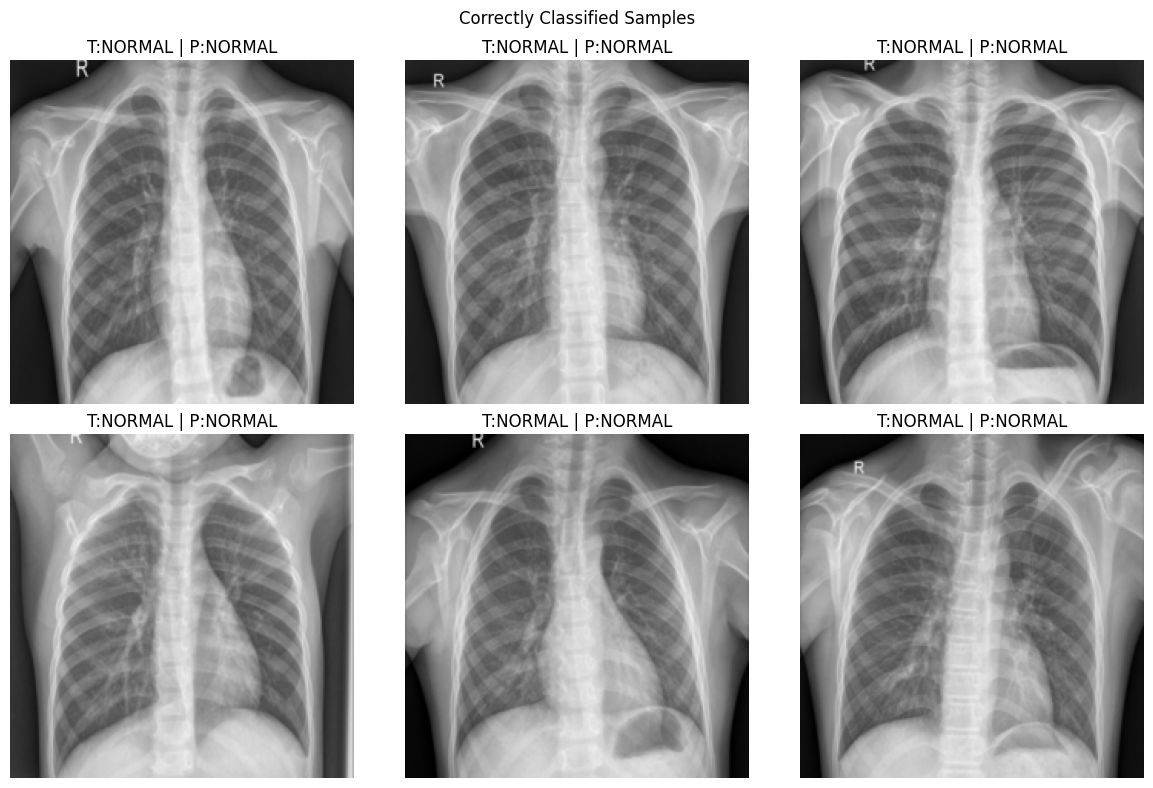

In [ ]:
# =========================================================
# CELL 30: CORRECTLY CLASSIFIED SAMPLES
# =========================================================
correct_idx = np.where(y_true == y_pred)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(correct_idx[:6]):
    img, label = test_dataset[idx]
    img_disp = img.permute(1, 2, 0).numpy()
    img_disp = (img_disp * 0.5) + 0.5
    img_disp = np.clip(img_disp, 0, 1)

    plt.subplot(2, 3, i+1)
    plt.imshow(img_disp)
    plt.title(f"T:{CLASS_NAMES[y_true[idx]]} | P:{CLASS_NAMES[y_pred[idx]]}")
    plt.axis("off")

plt.suptitle("Correctly Classified Samples")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 31: FINAL RESULTS SUMMARY TABLE
# =========================================================
print("==== Final Results Summary ====")
print(f"{'Metric':<20}{'Value'}")
print("-"*32)
print(f"{'Accuracy':<20}{accuracy:.4f}")
print(f"{'Precision':<20}{precision:.4f}")
print(f"{'Sensitivity':<20}{recall:.4f}")
print(f"{'Specificity':<20}{specificity:.4f}")
print(f"{'F1-Score':<20}{f1:.4f}")
print(f"{'ROC-AUC':<20}{roc_auc_val:.4f}")
print(f"{'PR-AUC':<20}{pr_auc:.4f}")
print(f"{'Inference (ms)':<20}{avg_time*1000:.2f}")

==== Final Results Summary ====
Metric              Value
--------------------------------
Accuracy            0.8013
Precision           0.7782
Sensitivity         0.9538
Specificity         0.5470
F1-Score            0.8571
ROC-AUC             0.9086
PR-AUC              0.9447
Inference (ms)      1.59
